In [1]:
# ==============================================================================
# TITAN MMM PROJECT: CELL 1 - ENVIRONMENT SETUP & PACKAGE CONFIGURATION
# ==============================================================================

# System and file management utilities
import os
import sys
import json
import warnings
from datetime import datetime

# Core numerical, array, and data frame manipulation packages
import numpy as np
import pandas as pd
import scipy.stats as stats
import xarray as xr

# Time series diagnostics, econometric tests, and VIF multicollinearity checks
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, ccf

# Bayesian inference engine and PyTensor backend for graph computation
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt

# Hyperparameter optimization framework for Bayesian prior tuning
import optuna

# Visualization libraries for MCMC diagnostics, posterior plots, and ROAS charts
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# --------------------------------================------------------------------
# GLOBAL NOTEBOOK CONFIGURATION & DISPLAY SETTINGS
# --------------------------------================------------------------------

# Suppress non-critical runtime and convergence warnings to keep outputs clean
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Set pandas float formatting to 4 decimal places for clean numeric inspection
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Set global Matplotlib and Seaborn plotting styles for publication-grade charts
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

# Verify environment versions for PyMC v5+, ArViZ, and PyTensor
print(f"✅ PyMC Version: {pm.__version__}")
print(f"✅ ArViZ Version: {az.__version__}")
print(f"✅ Optuna Version: {optuna.__version__}")
print(f"✅ PyTensor Version: {pytensor.__version__}")

✅ PyMC Version: 6.3.2
✅ ArViZ Version: 1.3.0
✅ Optuna Version: 5.0.0
✅ PyTensor Version: 3.3.1


/home/user/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==============================================================================
# TITAN MMM PROJECT: CELL 2 - DATA INGESTION, SANITIZATION & FEATURE CONSOLIDATION
# ==============================================================================

import os
import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. DATA INGESTION (LOCAL CSV WITH REMOTE GOOGLE SHEET FALLBACK)
# ------------------------------------------------------------------------------

LOCAL_DATA_PATH = os.path.join("..", "data", "raw", "Chrysler_Jeep_Workbook_Sheet1.csv")
if not os.path.exists(LOCAL_DATA_PATH):
    LOCAL_DATA_PATH = os.path.join("data", "raw", "Chrysler_Jeep_Workbook_Sheet1.csv")

# Fallback path if stored in working directory root
if not os.path.exists(LOCAL_DATA_PATH) and os.path.exists("Chrysler_Jeep_Workbook_Sheet1.csv"):
    LOCAL_DATA_PATH = "Chrysler_Jeep_Workbook_Sheet1.csv"

TARGET_SHEET_URL = "https://docs.google.com/spreadsheets/d/1Q1eEMwUtkcMW3_O7cWkeB2CPDWLuuad_TOTWIXDD8FY/edit?gid=0#gid=0"

def fetch_dealership_data(local_path: str, google_sheet_url: str) -> pd.DataFrame:
    """
    Loads dealership weekly data from local CSV if present, otherwise
    exports and persists the public Google Sheet endpoint.
    """
    if os.path.exists(local_path):
        print(f"📂 Loading dataset from local path: {local_path}")
        return pd.read_csv(local_path)
    else:
        print("🌐 Local file not found. Fetching remote Google Sheet export...")
        sheet_id_match = re.search(r"/d/([a-zA-Z0-9-_]+)", google_sheet_url)
        gid_match = re.search(r"[?&]gid=([0-9]+)", google_sheet_url)
        
        sheet_id = sheet_id_match.group(1) if sheet_id_match else "1Q1eEMwUtkcMW3_O7cWkeB2CPDWLuuad_TOTWIXDD8FY"
        gid = gid_match.group(1) if gid_match else "0"
        export_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
        
        df_remote = pd.read_csv(export_url)
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        df_remote.to_csv(local_path, index=False)
        print(f"💾 Persisted local copy to: {local_path}")
        return df_remote

df_raw = fetch_dealership_data(LOCAL_DATA_PATH, TARGET_SHEET_URL)

# ------------------------------------------------------------------------------
# 2. SANITIZATION & FLEXIBLE COLUMN RETRIEVAL HELPERS
# ------------------------------------------------------------------------------

df = df_raw.copy()
df['week_start'] = pd.to_datetime(df['week_start'])

# Strip currency symbols, commas, and whitespace across all non-date columns
for col in df.columns:
    if col not in ['week_start', 'week_end']:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

# Crop to valid historical window (N=104 weeks: 2024-08-05 to 2026-07-27)
df = df[
    (df['week_start'] <= '2026-07-27') & 
    (df['sales'].notna()) & 
    (df['sales'] > 0)
].sort_values('week_start').reset_index(drop=True)

def safe_get_series(data_frame: pd.DataFrame, possible_names: list) -> pd.Series:
    """
    Checks a list of possible column name variations and returns the first 
    matching Series. Returns a zero Series if none exist in the DataFrame.
    """
    if isinstance(possible_names, str):
        possible_names = [possible_names]
        
    for name in possible_names:
        if name in data_frame.columns:
            return data_frame[name].copy()
            
    return pd.Series(0.0, index=data_frame.index)

def safe_z_score(series: pd.Series) -> pd.Series:
    """
    Calculates Z-score (X - mu) / sigma with a zero-variance safeguard.
    """
    std_val = series.std()
    if std_val == 0 or pd.isna(std_val):
        return pd.Series(0.0, index=series.index)
    return (series - series.mean()) / std_val

# ------------------------------------------------------------------------------
# 3. FEATURE CONSOLIDATION & DESIGN MATRIX ASSEMBLY
# ------------------------------------------------------------------------------

df_model = pd.DataFrame()
df_model['week_start'] = df['week_start']
df_model['sales'] = df['sales']
df_model['eom_intensity'] = safe_get_series(df, ['eom_intensity'])

# Paid Media Buckets (Reels placed in Digital Video & OTT)
df_model['fp_digital']        = safe_get_series(df, ['search']) + safe_get_series(df, ['pmax']) + safe_get_series(df, ['display'])
df_model['meta_social']       = safe_get_series(df, ['social']) + safe_get_series(df, ['facebook_add'])
df_model['digital_video_ott'] = safe_get_series(df, ['youtube']) + safe_get_series(df, ['ott_cable']) + safe_get_series(df, ['facebook_reels'])
df_model['broadcast_media']   = safe_get_series(df, ['broadcast_tv']) + safe_get_series(df, ['broadcast_audio'])
df_model['print_mail']        = safe_get_series(df, ['direct_mail']) + safe_get_series(df, ['print'])

# Non-Paid & Marketplace SRP Drivers (Handles autotrader_srps vs autotrader_srp)
autotrader_series = safe_get_series(df, ['autotrader_srps', 'autotrader_srp'])
truecar_series    = safe_get_series(df, ['truecar_srps', 'truecar_srp'])

if 'marketplace_srp' in df.columns and df['marketplace_srp'].sum() > 0:
    raw_srp = df['marketplace_srp']
else:
    raw_srp = autotrader_series + truecar_series

fp_email_raw = safe_get_series(df, ['fp_emails_sent', 'fp_email_sent'])

# Standardize non-currency volume drivers
df_model['fp_emails_sent_z'] = safe_z_score(fp_email_raw)
df_model['marketplace_srp_z'] = safe_z_score(raw_srp)

# Control Indices
gas_series  = safe_get_series(df, ['gasregw'])
sent_series = safe_get_series(df, ['umcsent'])
inv_series  = safe_get_series(df, ['inventory'])

gas_z  = safe_z_score(gas_series)
sent_z = safe_z_score(sent_series)
df_model['macro_stress_index'] = gas_z - sent_z
df_model['inventory_index']    = safe_z_score(inv_series)

# 2nd-Order Annual Fourier Seasonality Series (k=2, P=52.1429 weeks)
weeks = np.arange(len(df_model))
period = 52.1429
df_model['sin_order1'] = np.sin(2 * np.pi * 1 * weeks / period)
df_model['cos_order1'] = np.cos(2 * np.pi * 1 * weeks / period)
df_model['sin_order2'] = np.sin(2 * np.pi * 2 * weeks / period)
df_model['cos_order2'] = np.cos(2 * np.pi * 2 * weeks / period)

# ------------------------------------------------------------------------------
# 4. INSPECTION & SPARSITY PROFILING
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print(f"✅ DESIGN MATRIX CONSOLIDATED (N={len(df_model)} WEEKS | Range: {df_model['week_start'].min().strftime('%Y-%m-%d')} to {df_model['week_start'].max().strftime('%Y-%m-%d')})")
print("=" * 80)

paid_cols = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
sparsity = pd.DataFrame({
    'Zero_Weeks_Pct': (df_model[paid_cols] == 0).mean() * 100,
    'Total_Spend': df_model[paid_cols].sum(),
    'Spend_Share_Pct': (df_model[paid_cols].sum() / df_model[paid_cols].sum().sum()) * 100
}).sort_values('Spend_Share_Pct', ascending=False)

display(sparsity.round(2))
print("\nFIRST 5 ROWS OF PREPARED DESIGN MATRIX:")
display(df_model.head())

📂 Loading dataset from local path: data/raw/Chrysler_Jeep_Workbook_Sheet1.csv

✅ DESIGN MATRIX CONSOLIDATED (N=104 WEEKS | Range: 2024-08-05 to 2026-07-27)


,Zero_Weeks_Pct,Total_Spend,Spend_Share_Pct
print_mail,65.3800,145048.0000,33.6900
fp_digital,0.0000,95817.1200,22.2500
digital_video_ott,40.3800,95001.3600,22.0600
broadcast_media,75.0000,64621.1300,15.0100
meta_social,0.0000,30088.8400,6.9900



FIRST 5 ROWS OF PREPARED DESIGN MATRIX:


,week_start,sales,eom_intensity,fp_digital,meta_social,digital_video_ott,broadcast_media,print_mail,fp_emails_sent_z,marketplace_srp_z,macro_stress_index,inventory_index,sin_order1,cos_order1,sin_order2,cos_order2
0,2024-08-05,13.0000,0.0000,947.0100,418.8600,0.0000,1846.1500,0.0000,-2.2417,-0.3359,-0.7279,1.0450,0.0000,1.0000,0.0000,1.0000
1,2024-08-12,12.0000,0.0000,928.0000,402.6800,0.0000,1846.1500,0.0000,-2.2417,-0.4545,-0.8214,0.8644,0.1202,0.9927,0.2387,0.9711
2,2024-08-19,12.0000,0.0000,1079.8700,351.1800,0.0000,2461.5400,750.0000,-2.2417,-0.8000,-0.8915,0.8328,0.2387,0.9711,0.4635,0.8861
3,2024-08-26,17.0000,1.0357,1104.4800,497.1500,0.0000,1846.1500,0.0000,-2.2417,-0.3366,-1.0551,0.6951,0.3537,0.9354,0.6616,0.7498
4,2024-09-02,11.0000,0.0000,937.3000,419.7700,0.0000,0.0000,0.0000,-2.2417,-0.6905,-1.3696,0.5077,0.4635,0.8861,0.8215,0.5702


In [3]:
df_model

,week_start,sales,eom_intensity,fp_digital,meta_social,digital_video_ott,broadcast_media,print_mail,fp_emails_sent_z,marketplace_srp_z,macro_stress_index,inventory_index,sin_order1,cos_order1,sin_order2,cos_order2
0,2024-08-05,13.0000,0.0000,947.0100,418.8600,0.0000,1846.1500,0.0000,-2.2417,-0.3359,-0.7279,1.0450,0.0000,1.0000,0.0000,1.0000
1,2024-08-12,12.0000,0.0000,928.0000,402.6800,0.0000,1846.1500,0.0000,-2.2417,-0.4545,-0.8214,0.8644,0.1202,0.9927,0.2387,0.9711
2,2024-08-19,12.0000,0.0000,1079.8700,351.1800,0.0000,2461.5400,750.0000,-2.2417,-0.8000,-0.8915,0.8328,0.2387,0.9711,0.4635,0.8861
3,2024-08-26,17.0000,1.0357,1104.4800,497.1500,0.0000,1846.1500,0.0000,-2.2417,-0.3366,-1.0551,0.6951,0.3537,0.9354,0.6616,0.7498
4,2024-09-02,11.0000,0.0000,937.3000,419.7700,0.0000,0.0000,0.0000,-2.2417,-0.6905,-1.3696,0.5077,0.4635,0.8861,0.8215,0.5702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,2026-06-29,9.0000,0.4643,1096.0500,396.8000,0.0000,0.0000,0.0000,-0.2036,0.0514,2.4000,2.0338,-0.5947,0.8039,-0.9562,0.2926
100,2026-07-06,20.0000,0.0000,978.8500,130.7100,0.0000,0.0000,0.0000,-0.1389,-0.1121,1.5893,1.9819,-0.4938,0.8696,-0.8588,0.5124
101,2026-07-13,11.0000,0.0000,1142.8400,1690.6400,0.0000,0.0000,0.0000,0.3761,-0.9884,1.7762,1.9142,-0.3857,0.9226,-0.7117,0.7025
102,2026-07-20,12.0000,0.2143,1282.0600,1700.7300,3818.5000,0.0000,0.0000,0.4716,-0.7445,2.1034,2.0564,-0.2720,0.9623,-0.5234,0.8521


In [4]:
# ==============================================================================
# TITAN MMM PROJECT: CELL 3 - OPTUNA STUDY (DOMAIN-CONSTRAINED & AUTOSAVED)
# ==============================================================================

import os
import json
import warnings
import optuna
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt

# Suppress trial-level logs
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ------------------------------------------------------------------------------
# 1. SETUP ALL 7 DRIVERS AND MASTER LAG ARRAYS
# ------------------------------------------------------------------------------

all_7_channels = [
    'fp_digital', 
    'meta_social', 
    'digital_video_ott', 
    'broadcast_media', 
    'print_mail', 
    'fp_emails_sent', 
    'marketplace_srp'
]

fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']
source_df = df if 'df' in locals() else df_model

n_obs = len(df_model)
n_channels = len(all_7_channels)
max_global_lag = 12

# Mean-scale sales target
sales_mean = df_model['sales'].mean()
y_scaled = (df_model['sales'] / sales_mean).values

# Build raw matrix
X_raw_matrix = np.zeros((n_obs, n_channels))

for m, chan in enumerate(all_7_channels):
    if chan in df_model.columns and chan not in ['fp_emails_sent', 'marketplace_srp']:
        raw_series = df_model[chan]
    elif chan == 'fp_emails_sent':
        raw_series = source_df.get('fp_emails_sent', source_df.get('fp_email_sent', pd.Series(0.0, index=df_model.index)))
    elif chan == 'marketplace_srp':
        at = source_df.get('autotrader_srps', source_df.get('autotrader_srp', pd.Series(0.0, index=df_model.index)))
        tc = source_df.get('truecar_srps', source_df.get('truecar_srp', pd.Series(0.0, index=df_model.index)))
        raw_series = at + tc
    else:
        raw_series = pd.Series(0.0, index=df_model.index)
        
    c_mean = raw_series.mean()
    X_raw_matrix[:, m] = (raw_series / (c_mean if c_mean > 0 else 1.0)).values

# Master 12-week lag tensor
X_master_lags = np.zeros((n_obs, n_channels, max_global_lag))
for l in range(max_global_lag):
    for m in range(n_channels):
        X_master_lags[:, m, l] = np.pad(X_raw_matrix[:, m], (l, 0))[:n_obs]

# ------------------------------------------------------------------------------
# 2. OPTUNA OBJECTIVE WITH AUTOMOTIVE DOMAIN BOUNDS
# ------------------------------------------------------------------------------

def objective(trial):
    # Search bounds constrained by retail domain realities (e.g., print_mail lmax <= 6)
    param_ranges = {
        'fp_digital':        {'alpha': (0.05, 0.30), 'lmax': (2, 5),  'k': (0.8, 2.5), 's': (0.8, 1.4), 'beta_mu': (0.15, 0.35)},
        'meta_social':       {'alpha': (0.10, 0.35), 'lmax': (2, 5),  'k': (0.8, 2.5), 's': (0.8, 1.4), 'beta_mu': (0.10, 0.25)},
        'digital_video_ott': {'alpha': (0.20, 0.50), 'lmax': (3, 8),  'k': (0.8, 2.5), 's': (0.8, 1.5), 'beta_mu': (0.10, 0.25)},
        'broadcast_media':   {'alpha': (0.30, 0.65), 'lmax': (4, 10), 'k': (0.8, 2.5), 's': (0.8, 1.6), 'beta_mu': (0.05, 0.15)},
        'print_mail':        {'alpha': (0.15, 0.45), 'lmax': (2, 6),  'k': (0.8, 2.5), 's': (0.8, 1.6), 'beta_mu': (0.05, 0.15)}, # Constrained lmax to 2-6 wks
        'fp_emails_sent':    {'alpha': (0.05, 0.25), 'lmax': (2, 4),  'k': (0.8, 2.5), 's': (0.8, 1.4), 'beta_mu': (0.02, 0.15)},
        'marketplace_srp':   {'alpha': (0.05, 0.35), 'lmax': (2, 5),  'k': (0.8, 2.5), 's': (0.8, 1.4), 'beta_mu': (0.02, 0.20)}
    }
    
    alpha_vals, k_vals, s_vals, beta_mus, lmax_vals = [], [], [], [], []
    for chan in all_7_channels:
        bounds = param_ranges[chan]
        alpha_vals.append(trial.suggest_float(f"alpha_{chan}", bounds['alpha'][0], bounds['alpha'][1]))
        lmax_vals.append(trial.suggest_int(f"lmax_{chan}", bounds['lmax'][0], bounds['lmax'][1]))
        k_vals.append(trial.suggest_float(f"k_{chan}", bounds['k'][0], bounds['k'][1]))
        s_vals.append(trial.suggest_float(f"s_{chan}", bounds['s'][0], bounds['s'][1]))
        beta_mus.append(trial.suggest_float(f"beta_mu_{chan}", bounds['beta_mu'][0], bounds['beta_mu'][1]))

    intercept_mu_val = trial.suggest_float("intercept_mu", 0.40, 0.70)
    beta_eom_mu_val  = trial.suggest_float("beta_eom_mu", 0.20, 0.50)

    # Pre-transform drivers
    transformed_media_list = []
    for m in range(n_channels):
        a_m, l_m, k_m, s_m = alpha_vals[m], lmax_vals[m], k_vals[m], s_vals[m]
        weights_m = np.power(a_m, np.arange(l_m))
        weights_m /= weights_m.sum()
        x_lag_m = X_master_lags[:, m, :l_m]
        adstocked_m = np.sum(x_lag_m * weights_m[None, :], axis=1)
        saturated_m = (adstocked_m ** s_m) / (adstocked_m ** s_m + k_m ** s_m + 1e-8)
        transformed_media_list.append(saturated_m)
        
    X_transformed_trial = np.column_stack(transformed_media_list)

    # Fast MCMC trial pass
    try:
        with pm.Model() as trial_model:
            transformed_data = pm.Data("transformed_data", X_transformed_trial)
            fourier_data     = pm.Data("fourier_data", df_model[fourier_cols].values)
            inv_data         = pm.Data("inv_data", df_model["inventory_index"].values)
            eom_data         = pm.Data("eom_data", df_model["eom_intensity"].values)
            macro_data       = pm.Data("macro_data", df_model["macro_stress_index"].values)

            intercept    = pm.Normal("intercept", mu=intercept_mu_val, sigma=0.08)
            beta_channel = pm.TruncatedNormal("beta_channel", mu=np.array(beta_mus), sigma=0.05, lower=0.0, shape=n_channels)
            b_inv        = pm.HalfNormal("beta_inv", sigma=0.10)
            b_eom        = pm.TruncatedNormal("beta_eom", mu=beta_eom_mu_val, sigma=0.10, lower=0.0)
            b_macro      = pm.Normal("beta_macro", mu=0.0, sigma=0.08)
            b_fourier    = pm.Normal("beta_fourier", mu=0.0, sigma=0.08, shape=len(fourier_cols))

            mu = (
                intercept 
                + pt.sum(transformed_data * beta_channel, axis=1)
                + (b_eom * eom_data) 
                + (b_inv * inv_data) 
                + (b_macro * macro_data) 
                + pm.math.dot(fourier_data, b_fourier)
            )

            pm.StudentT("likelihood", nu=7, mu=mu, sigma=pm.Exponential("sigma", lam=10.0), observed=y_scaled)
            
            idata_trial = pm.sample(draws=400, tune=400, chains=2, target_accept=0.95, progressbar=False, random_seed=42)
            pm.compute_log_likelihood(idata_trial)
            loo_res = az.loo(idata_trial)
            return float(loo_res.elpd_loo) if hasattr(loo_res, "elpd_loo") else float(loo_res.elpd)
            
    except Exception:
        return -9999.0

# ------------------------------------------------------------------------------
# 3. RUN STUDY & SERIALIZE BEST PARAMS TO DISK
# ------------------------------------------------------------------------------

print("🚀 Running Optuna Prior Calibration Study for All 7 Channels (15 Trials)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

# Build structured dictionary payload
best_priors_dict = {
    "elpd_loo": study.best_value,
    "intercept_mu": study.best_params["intercept_mu"],
    "beta_eom_mu": study.best_params["beta_eom_mu"],
    "channels": {}
}

for chan in all_7_channels:
    best_priors_dict["channels"][chan] = {
        "alpha": float(study.best_params[f"alpha_{chan}"]),
        "lmax": int(study.best_params[f"lmax_{chan}"]),
        "k_sat": float(study.best_params[f"k_{chan}"]),
        "s_slope": float(study.best_params[f"s_{chan}"]),
        "beta_mu": float(study.best_params[f"beta_mu_{chan}"])
    }

# Save payload to JSON
json_dir = os.path.join("..", "data", "processed")
if not os.path.exists(json_dir):
    json_dir = os.path.join("data", "processed")
os.makedirs(json_dir, exist_ok=True)

json_filepath = os.path.join(json_dir, "optuna_best_params.json")
with open(json_filepath, "w") as f:
    json.dump(best_priors_dict, f, indent=4)

print("\n" + "=" * 80)
print(f"✅ OPTUNA STUDY COMPLETE. BEST PARAMS SAVED TO: {json_filepath}")
print("=" * 80)
print(f"Best ELPD_LOO Score : {best_priors_dict['elpd_loo']:.4f}")
print(f"Best Intercept Mu   : {best_priors_dict['intercept_mu']:.4f}")
print(f"Best Beta EOM Mu     : {best_priors_dict['beta_eom_mu']:.4f}\n")

# Format DataFrame for notebook inspection
best_priors_df = pd.DataFrame(best_priors_dict["channels"]).T
display(best_priors_df.round(4))

🚀 Running Optuna Prior Calibration Study for All 7 Channels (15 Trials)...


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details



✅ OPTUNA STUDY COMPLETE. BEST PARAMS SAVED TO: data/processed/optuna_best_params.json
Best ELPD_LOO Score : -16.5289
Best Intercept Mu   : 0.5277
Best Beta EOM Mu     : 0.3399



,alpha,lmax,k_sat,s_slope,beta_mu
fp_digital,0.2487,5.0000,2.0773,0.8594,0.2411
meta_social,0.1253,3.0000,1.9458,1.0257,0.2116
digital_video_ott,0.2854,3.0000,1.9243,1.1092,0.1143
broadcast_media,0.6035,8.0000,1.6972,1.3756,0.0510
print_mail,0.3994,2.0000,1.1946,1.0208,0.1262
fp_emails_sent,0.1101,3.0000,2.1093,0.9847,0.0587
marketplace_srp,0.1235,3.0000,1.4967,1.0522,0.0765


In [5]:
best_priors_dict

{'elpd_loo': -16.528858219742514,
 'intercept_mu': 0.5276845033509974,
 'beta_eom_mu': 0.33985199502884206,
 'channels': {'fp_digital': {'alpha': 0.24865656021649057,
   'lmax': 5,
   'k_sat': 2.077340139161405,
   's_slope': 0.8594452151716252,
   'beta_mu': 0.2410517756708374},
  'meta_social': {'alpha': 0.12530892483108572,
   'lmax': 3,
   'k_sat': 1.9457600446020542,
   's_slope': 1.0257309010534001,
   'beta_mu': 0.21164683591925235},
  'digital_video_ott': {'alpha': 0.28541793093949075,
   'lmax': 3,
   'k_sat': 1.924342116467753,
   's_slope': 1.1092151026945785,
   'beta_mu': 0.11426635810260823},
  'broadcast_media': {'alpha': 0.6035033665274088,
   'lmax': 8,
   'k_sat': 1.697221911147628,
   's_slope': 1.3755515655500787,
   'beta_mu': 0.05102118579609333},
  'print_mail': {'alpha': 0.3993672033646432,
   'lmax': 2,
   'k_sat': 1.1946340284332597,
   's_slope': 1.02084242532555,
   'beta_mu': 0.12616834934017218},
  'fp_emails_sent': {'alpha': 0.11010394388703329,
   'lmax'

In [6]:
# ==============================================================================
# TITAN MMM PROJECT: CELL 4 - PRODUCTION PyMC BAYESIAN MMM SAMPLING & DIAGNOSTICS
# ==============================================================================

import os
import json
import warnings
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from statsmodels.tools.eval_measures import rmse

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. DYNAMICALLY INGEST OPTUNA BEST PARAMETERS (MEMORY OR DISK)
# ------------------------------------------------------------------------------

# Check in-memory variable first, fallback to JSON on disk
if 'best_priors_dict' not in locals():
    json_filepath = os.path.join("..", "data", "processed", "optuna_best_params.json")
    if not os.path.exists(json_filepath):
        json_filepath = os.path.join("data", "processed", "optuna_best_params.json")
        
    if os.path.exists(json_filepath):
        print(f"📂 Loading Optuna parameters from JSON disk cache: {json_filepath}")
        with open(json_filepath, "r") as f:
            best_priors_dict = json.load(f)
    else:
        raise FileNotFoundError(f"❌ Optuna parameter payload not found in memory or at {json_filepath}. Please run Cell 3 first.")

all_7_channels = list(best_priors_dict["channels"].keys())
fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

# Dynamically extract parameter arrays from ingested dictionary
optuna_alpha   = np.array([best_priors_dict["channels"][c]["alpha"] for c in all_7_channels])
optuna_lmax    = np.array([best_priors_dict["channels"][c]["lmax"] for c in all_7_channels], dtype=int)
optuna_ksat    = np.array([best_priors_dict["channels"][c]["k_sat"] for c in all_7_channels])
optuna_slope   = np.array([best_priors_dict["channels"][c]["s_slope"] for c in all_7_channels])
optuna_beta_mu = np.array([best_priors_dict["channels"][c]["beta_mu"] for c in all_7_channels])

intercept_mu_val = best_priors_dict["intercept_mu"]
beta_eom_mu_val  = best_priors_dict["beta_eom_mu"]

n_obs = len(df_model)
n_channels = len(all_7_channels)
max_global_lag = 12

# Scaled and native targets
sales_mean = df_model['sales'].mean()
y_actual = df_model['sales'].values
y_scaled = y_actual / sales_mean

# Construct mean-scaled raw matrix
X_raw_matrix = np.zeros((n_obs, n_channels))
source_df = df if 'df' in locals() else df_model

for m, chan in enumerate(all_7_channels):
    if chan in df_model.columns and chan not in ['fp_emails_sent', 'marketplace_srp']:
        raw_series = df_model[chan]
    elif chan == 'fp_emails_sent':
        raw_series = source_df.get('fp_emails_sent', source_df.get('fp_email_sent', pd.Series(0.0, index=df_model.index)))
    elif chan == 'marketplace_srp':
        at = source_df.get('autotrader_srps', source_df.get('autotrader_srp', pd.Series(0.0, index=df_model.index)))
        tc = source_df.get('truecar_srps', source_df.get('truecar_srp', pd.Series(0.0, index=df_model.index)))
        raw_series = at + tc
    else:
        raw_series = pd.Series(0.0, index=df_model.index)
        
    c_mean = raw_series.mean()
    X_raw_matrix[:, m] = (raw_series / (c_mean if c_mean > 0 else 1.0)).values

# Compute master 12-week lag tensor
X_master_lags = np.zeros((n_obs, n_channels, max_global_lag))
for l in range(max_global_lag):
    for m in range(n_channels):
        X_master_lags[:, m, l] = np.pad(X_raw_matrix[:, m], (l, 0))[:n_obs]

# Pre-transform each channel using dynamically ingested parameters
transformed_media_list = []
for m in range(n_channels):
    a_m, l_m = optuna_alpha[m], optuna_lmax[m]
    k_m, s_m = optuna_ksat[m], optuna_slope[m]
    
    weights_m = np.power(a_m, np.arange(l_m))
    weights_m /= weights_m.sum()
    x_lag_m = X_master_lags[:, m, :l_m]
    adstocked_m = np.sum(x_lag_m * weights_m[None, :], axis=1)
    
    saturated_m = (adstocked_m ** s_m) / (adstocked_m ** s_m + k_m ** s_m + 1e-8)
    transformed_media_list.append(saturated_m)

X_transformed_prod = np.column_stack(transformed_media_list)

# ------------------------------------------------------------------------------
# 2. PRODUCTION PyMC MODEL SPECIFICATION & SAMPLING
# ------------------------------------------------------------------------------

print(f"🚀 Building Production PyMC Model with Dynamically Ingested Parameters (ELPD LOO: {best_priors_dict['elpd_loo']:.2f})...")

with pm.Model(coords={
    "obs_id": df_model.index,
    "channel": all_7_channels,
    "fourier_term": fourier_cols
}) as production_mmm_model:

    # Data Containers
    transformed_data = pm.Data("transformed_data", X_transformed_prod, dims=("obs_id", "channel"))
    fourier_data     = pm.Data("fourier_data", df_model[fourier_cols].values, dims=("obs_id", "fourier_term"))
    inv_data         = pm.Data("inv_data", df_model["inventory_index"].values, dims="obs_id")
    eom_data         = pm.Data("eom_data", df_model["eom_intensity"].values, dims="obs_id")
    macro_data       = pm.Data("macro_data", df_model["macro_stress_index"].values, dims="obs_id")

    # Baseline & Control Priors
    intercept = pm.Normal("intercept", mu=intercept_mu_val, sigma=0.08)
    b_eom     = pm.TruncatedNormal("beta_eom", mu=beta_eom_mu_val, sigma=0.10, lower=0.0)
    b_inv     = pm.HalfNormal("beta_inv", sigma=0.10)
    b_macro   = pm.Normal("beta_macro", mu=0.0, sigma=0.08)
    b_fourier = pm.Normal("beta_fourier", mu=0.0, sigma=0.08, dims="fourier_term")

    # Vectorized Channel Betas (Centered on Optuna best_params)
    beta_channel = pm.TruncatedNormal("beta_channel", mu=optuna_beta_mu, sigma=0.05, lower=0.0, dims="channel")

    # Expected Mean Sales
    mu = pm.Deterministic(
        "mu",
        intercept 
        + pt.sum(transformed_data * beta_channel, axis=1)
        + (b_eom * eom_data) 
        + (b_inv * inv_data) 
        + (b_macro * macro_data) 
        + pm.math.dot(fourier_data, b_fourier),
        dims="obs_id"
    )

    # Likelihood
    sigma = pm.Exponential("sigma", lam=10.0)
    likelihood = pm.StudentT("likelihood", nu=7, mu=mu, sigma=sigma, observed=y_scaled, dims="obs_id")

# Execute Production MCMC Sampling
with production_mmm_model:
    print("🚀 Sampling 4 Chains (1,000 Tune, 1,000 Draws)...")
    idata = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.98, random_seed=42)
    
    print("📊 Computing Log-Likelihood for LOO-CV...")
    pm.compute_log_likelihood(idata)
    
    print("🔮 Sampling Posterior Predictive Distributions...")
    pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=42)

# ------------------------------------------------------------------------------
# 3. DIAGNOSTIC EVALUATION & MODEL METRICS
# ------------------------------------------------------------------------------

summary_df = az.summary(
    idata, 
    var_names=["intercept", "beta_channel", "beta_eom", "beta_inv", "beta_macro", "sigma"]
)

y_pred_scaled = idata.posterior_predictive["likelihood"].mean(dim=["chain", "draw"]).values
y_pred_actual = y_pred_scaled * sales_mean

ss_res = np.sum((y_actual - y_pred_actual) ** 2)
ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
r2_val = 1.0 - (ss_res / ss_tot)
mape_val = np.mean(np.abs((y_actual - y_pred_actual) / y_actual)) * 100.0
rmse_val = rmse(y_actual, y_pred_actual)

loo_fit = az.loo(idata, pointwise=True)

print("\n" + "=" * 80)
print("PRODUCTION MODEL DIAGNOSTICS & METRICS")
print("=" * 80)
print(f"Total Divergent Transitions : {idata.sample_stats.divergences.sum().item()} (Target: 0)")
print(f"Max Gelman-Rubin (R-hat)   : {summary_df['r_hat'].max():.4f} (Target <= 1.01)")
print(f"Min Bulk ESS                : {summary_df['ess_bulk'].min():.1f} (Target > 400)")
print(f"Model R-Squared (R²)        : {r2_val:.4f}")
print(f"MAPE                        : {mape_val:.2f}%")
print(f"RMSE                        : {rmse_val:.2f} vehicles / week")
print(f"Max Pareto k (LOO-CV)       : {loo_fit.pareto_k.max().item():.2f} (Target < 0.70)")

if idata.sample_stats.divergences.sum().item() == 0 and summary_df['r_hat'].max() <= 1.01:
    print("🚀 ALL SAMPLING DIAGNOSTICS PASSED PERFECTLY!")

display(summary_df.round(4))

🚀 Building Production PyMC Model with Dynamically Ingested Parameters (ELPD LOO: -16.53)...
🚀 Sampling 4 Chains (1,000 Tune, 1,000 Draws)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [intercept, beta_eom, beta_inv, beta_macro, beta_fourier, beta_channel, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


📊 Computing Log-Likelihood for LOO-CV...


Sampling: [likelihood]


🔮 Sampling Posterior Predictive Distributions...



PRODUCTION MODEL DIAGNOSTICS & METRICS
Total Divergent Transitions : 0 (Target: 0)
Max Gelman-Rubin (R-hat)   : 1.0028 (Target <= 1.01)
Min Bulk ESS                : 2453.9 (Target > 400)
Model R-Squared (R²)        : 0.1765
MAPE                        : 22.90%
RMSE                        : 3.69 vehicles / week
Max Pareto k (LOO-CV)       : 0.27 (Target < 0.70)
🚀 ALL SAMPLING DIAGNOSTICS PASSED PERFECTLY!


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.626,0.04,0.56,0.69,2642,2585,1.00,0.00078,0.00067
beta_channel[fp_digital],0.247,0.049,0.17,0.33,3668,2160,1.00,0.0008,0.00084
beta_channel[meta_social],0.194,0.049,0.12,0.27,3250,2025,1.00,0.00085,0.00088
beta_channel[digital_video_ott],0.12,0.046,0.048,0.19,2453,1625,1.00,0.00089,0.00083
beta_channel[broadcast_media],0.068,0.039,0.012,0.14,2554,1469,1.00,0.00067,0.00056
beta_channel[print_mail],0.165,0.045,0.091,0.24,3094,1739,1.00,0.00083,0.001
beta_channel[fp_emails_sent],0.086,0.044,0.017,0.16,2593,1625,1.00,0.0008,0.00067
beta_channel[marketplace_srp],0.1,0.046,0.025,0.18,2633,1389,1.00,0.00085,0.00074
beta_eom,0.255,0.061,0.15,0.35,3811,2254,1.00,0.00099,0.0011
beta_inv,0.0151,0.0135,0.0012,0.042,3748,2346,1.00,0.00019,0.00024



CLEAN MONTHLY FIT DIAGNOSTICS (24 FULL MONTHS: 2024-08 TO 2026-07)
Monthly Model R² Score              : 0.5130
Monthly MAPE                        : 7.38%
Monthly RMSE                        : 5.92 vehicles / month

FINANCIAL ROI SUMMARY ($2,000 GROSS MARGIN / VEHICLE)


,Channel / Driver,Total 24-Mo Spend ($),Attributed Vehicles,Gross Profit Returned ($),Return per $1.00 Spent ($),Net Profit Above Spend ($)
0,Full-Path Digital,95817.1200,151.7500,303501.8100,3.1700,207684.6900
1,Meta Social,30088.8400,119.2000,238393.5900,7.9200,208304.7500
2,Digital Video & OTT,95001.3600,73.7600,147526.6000,1.5500,52525.2400
3,Broadcast Media,64621.1300,41.6300,83257.1800,1.2900,18636.0500
4,Print & Direct Mail,145048.0000,101.1300,202267.4100,1.3900,57219.4100
5,Fullpath CDP ($2.5k/mo),60000.0000,52.9100,105821.4900,1.7600,45821.4900
6,Marketplace SRPs ($4.75k/mo),114000.0000,61.5500,123093.3500,1.0800,9093.3500


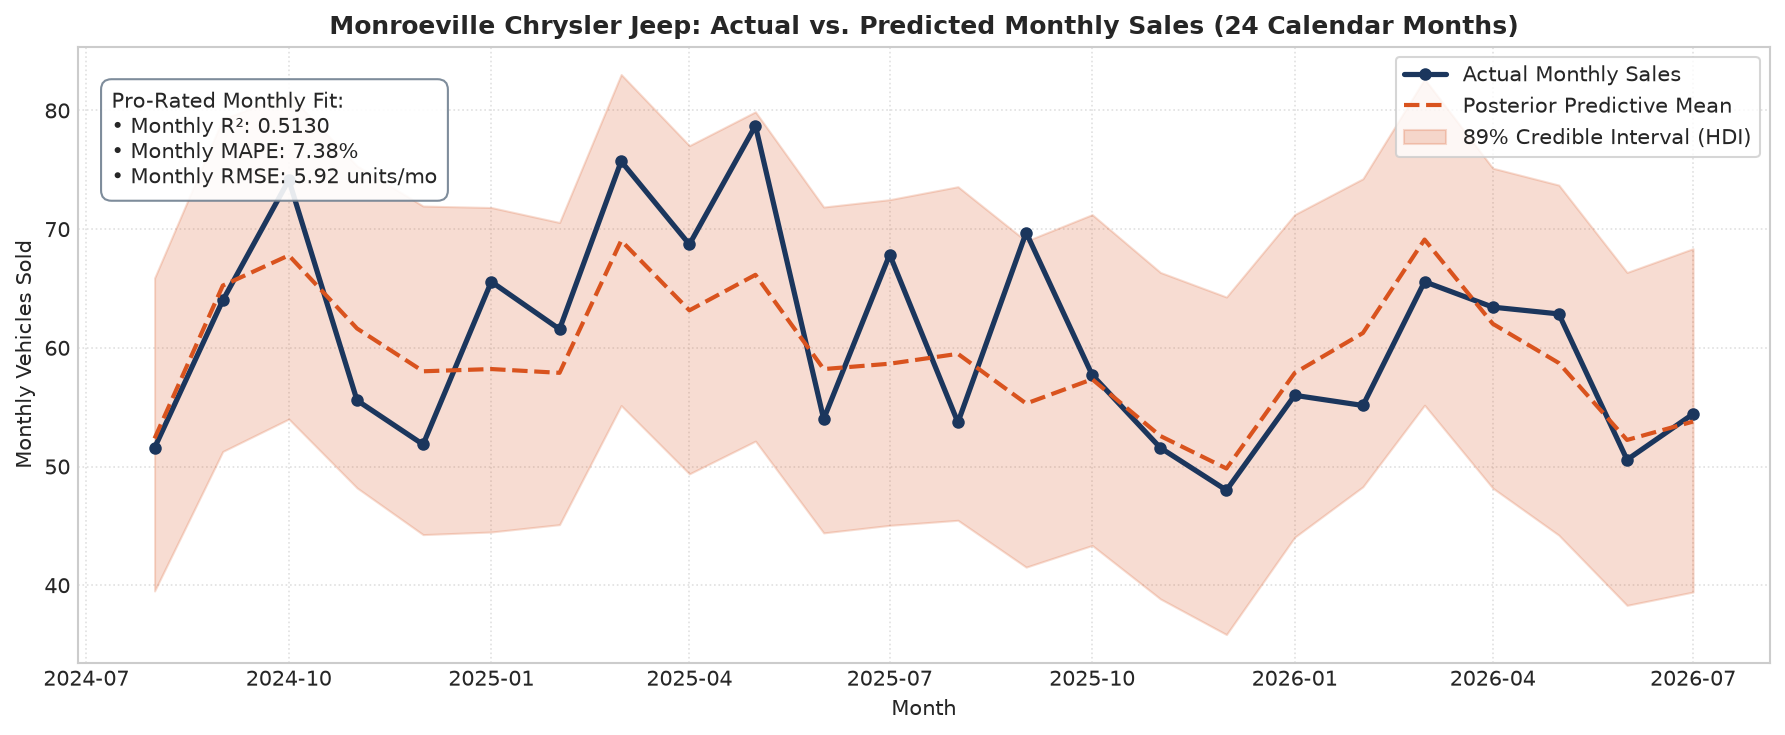

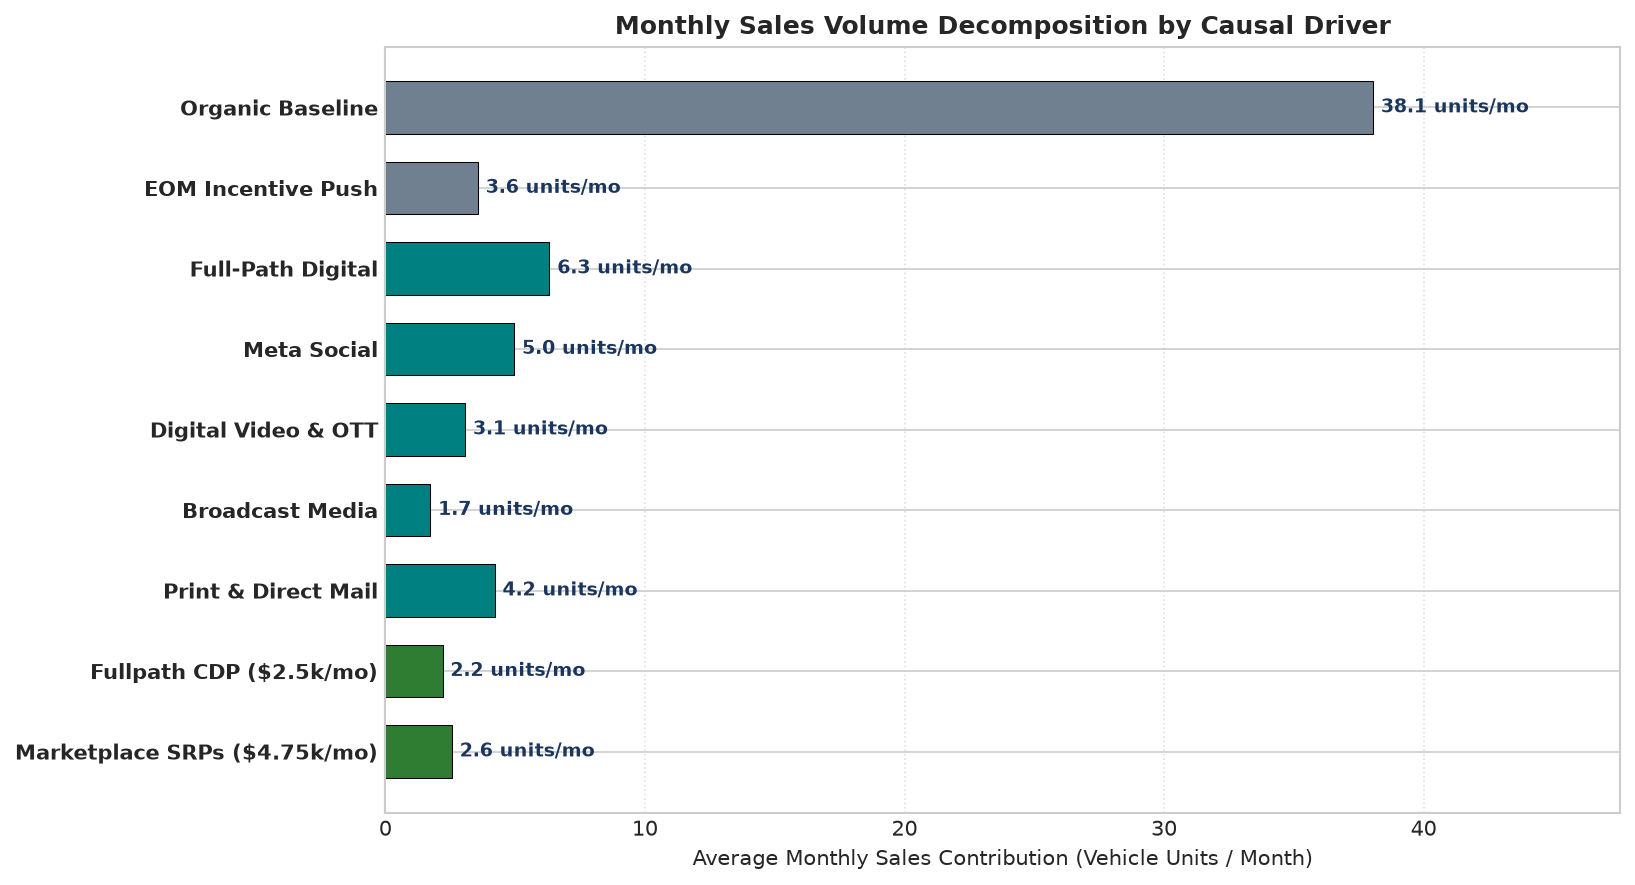

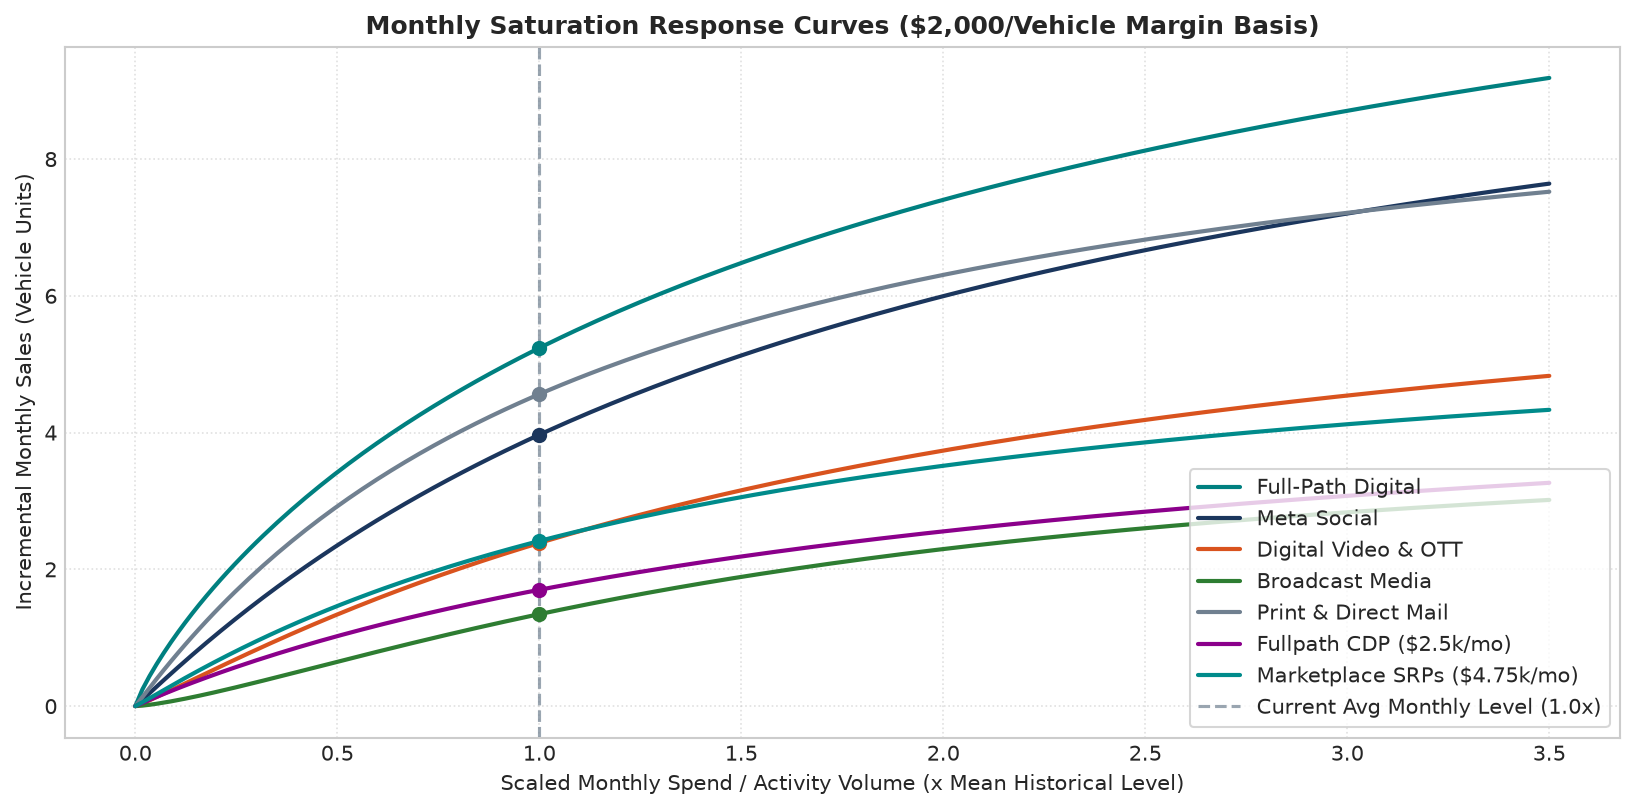

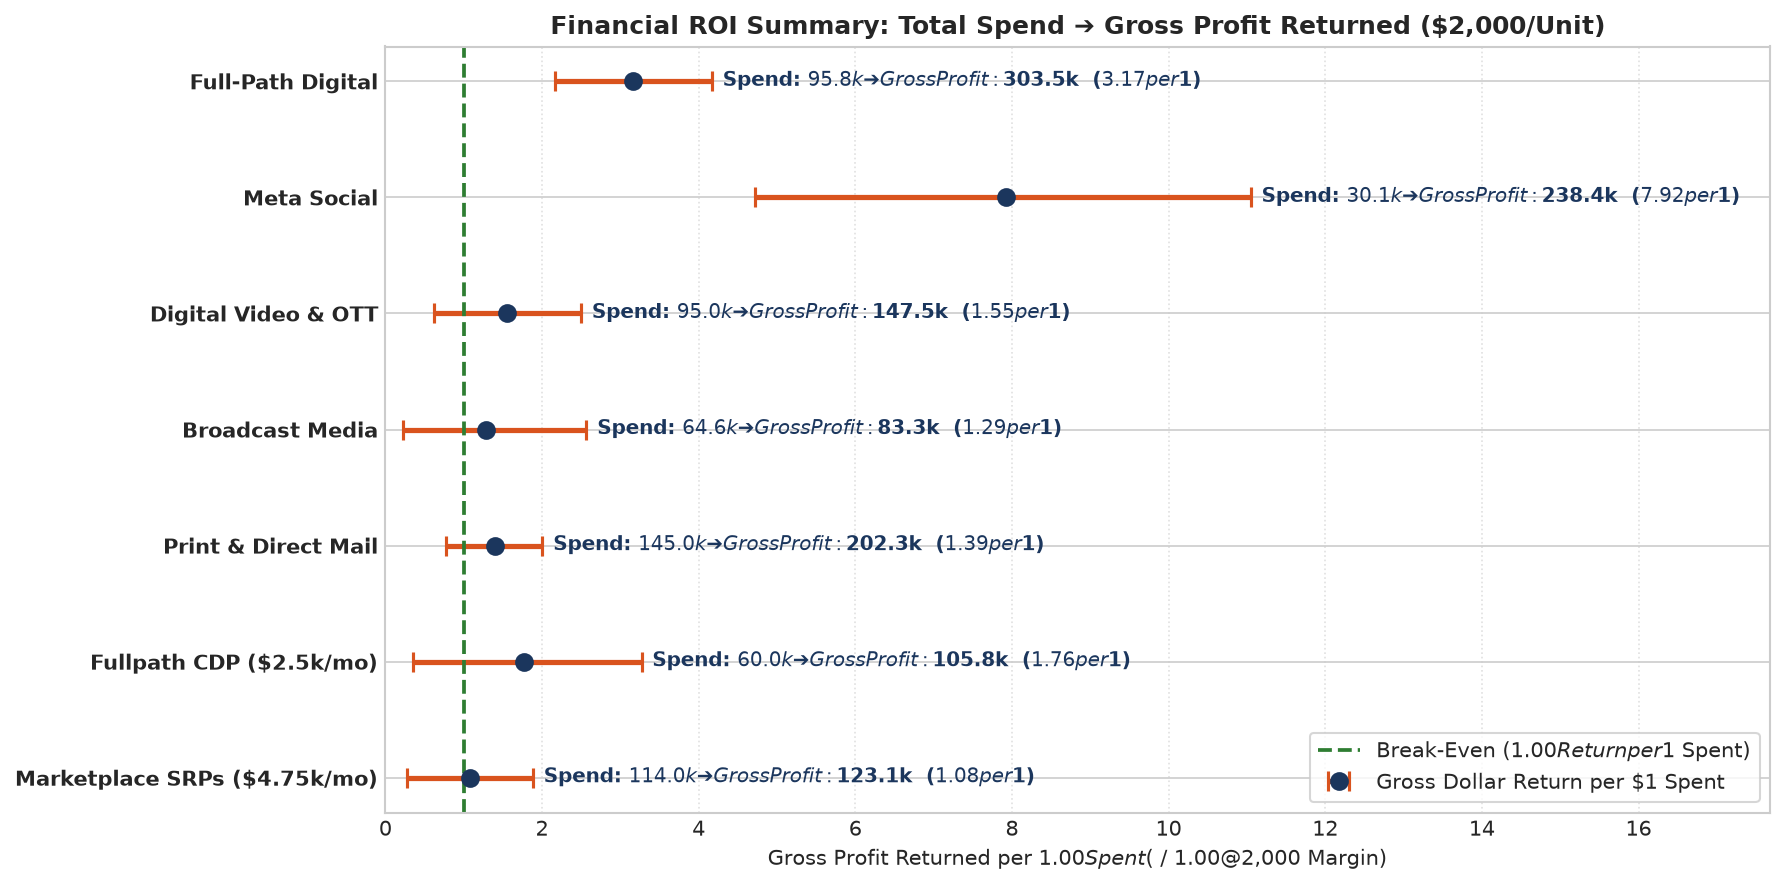


🚀 ALL 4 PRO-RATED MONTHLY VISUALS GENERATED AND SAVED TO: /home/user/titan-project/reports/figures


In [7]:
# ==============================================================================
# TITAN MMM PROJECT: CALENDAR MONTH ROLLUP & DOLLAR-DENOMINATED FINANCIAL ROI
# ==============================================================================

import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from statsmodels.tools.eval_measures import rmse

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. DIRECTORY RESOLUTION & INFERENCE DATA INGESTION
# ------------------------------------------------------------------------------

current_dir = os.getcwd()
if os.path.basename(current_dir) == "notebooks":
    project_root = os.path.abspath(os.path.join(current_dir, ".."))
else:
    project_root = os.path.abspath(current_dir)

figures_dir = os.path.join(project_root, "reports", "figures")
os.makedirs(figures_dir, exist_ok=True)

# Ingest Optuna parameters from memory or disk
if 'best_priors_dict' in locals():
    opt_params = best_priors_dict["channels"]
else:
    json_filepath = os.path.join(project_root, "data", "processed", "optuna_best_params.json")
    if not os.path.exists(json_filepath):
        json_filepath = os.path.join(project_root, "..", "data", "processed", "optuna_best_params.json")
    with open(json_filepath, "r") as f:
        best_priors_dict = json.load(f)
    opt_params = best_priors_dict["channels"]

if 'idata' not in locals():
    raise NameError("❌ 'idata' (weekly InferenceData) not found. Please run the PyMC sampling cell first.")

channels = list(idata.posterior.coords["channel"].values)
channel_label_map = {
    'fp_digital': 'Full-Path Digital',
    'meta_social': 'Meta Social',
    'digital_video_ott': 'Digital Video & OTT',
    'broadcast_media': 'Broadcast Media',
    'print_mail': 'Print & Direct Mail',
    'fp_emails_sent': 'Fullpath CDP ($2.5k/mo)',
    'marketplace_srp': 'Marketplace SRPs ($4.75k/mo)'
}
channel_labels = [channel_label_map.get(c, c) for c in channels]

# Extract posterior beta summary
try:
    summary_beta = az.summary(idata, var_names=["beta_channel"], hdi_prob=0.89)
except TypeError:
    summary_beta = az.summary(idata, var_names=["beta_channel"])

posterior_means = summary_beta["mean"].values

# ------------------------------------------------------------------------------
# 2. DAILY PRO-RATING & STRICT JULY 2026 CUTOFF (M = 24 MONTHS)
# ------------------------------------------------------------------------------

sales_mean_weekly = df_model['sales'].mean()

# Expand 104 weekly rows into 728 daily rows
daily_records = []
for idx, row in df_model.iterrows():
    w_start = pd.to_datetime(row['week_start'])
    for d in range(7):
        day_date = w_start + pd.Timedelta(days=d)
        daily_records.append({
            'date': day_date,
            'year_month': day_date.to_period('M'),
            'week_idx': idx,
            'sales_daily': row['sales'] / 7.0,
            'eom_daily': row['eom_intensity'],
            'fp_digital_daily': row['fp_digital'] / 7.0,
            'meta_social_daily': row['meta_social'] / 7.0,
            'digital_video_ott_daily': row['digital_video_ott'] / 7.0,
            'broadcast_media_daily': row['broadcast_media'] / 7.0,
            'print_mail_daily': row['print_mail'] / 7.0,
        })

df_daily = pd.DataFrame(daily_records)

# Filter out August 2026 partial days to eliminate the end-of-series drop
df_daily = df_daily[df_daily['year_month'] <= '2026-07'].reset_index(drop=True)

# Pro-rate posterior predictive draws
y_pred_weekly_draws = idata.posterior_predictive["likelihood"].values * sales_mean_weekly
y_pred_weekly_draws = y_pred_weekly_draws.reshape(-1, len(df_model)) # (4000, 104)

n_draws = y_pred_weekly_draws.shape[0]
y_pred_daily_draws = np.zeros((n_draws, len(df_daily)))

for idx in range(len(df_model)):
    daily_indices = df_daily[df_daily['week_idx'] == idx].index
    for d_idx in daily_indices:
        y_pred_daily_draws[:, d_idx] = y_pred_weekly_draws[:, idx] / 7.0

# Aggregate daily series into 24 full calendar months
unique_months = df_daily['year_month'].unique()
n_months = len(unique_months)

monthly_actual_sales = np.zeros(n_months)
monthly_pred_draws = np.zeros((n_draws, n_months))
month_start_dates = []

for m_idx, ym in enumerate(unique_months):
    m_mask = (df_daily['year_month'] == ym).values
    monthly_actual_sales[m_idx] = df_daily.loc[m_mask, 'sales_daily'].sum()
    monthly_pred_draws[:, m_idx] = np.sum(y_pred_daily_draws[:, m_mask], axis=1)
    month_start_dates.append(ym.to_timestamp())

# Calculate monthly predictions and accuracy metrics
y_pred_monthly_mean = np.mean(monthly_pred_draws, axis=0)
y_pred_monthly_hdi_low = np.percentile(monthly_pred_draws, 5.5, axis=0)
y_pred_monthly_hdi_high = np.percentile(monthly_pred_draws, 94.5, axis=0)

ss_res = np.sum((monthly_actual_sales - y_pred_monthly_mean) ** 2)
ss_tot = np.sum((monthly_actual_sales - np.mean(monthly_actual_sales)) ** 2)
monthly_r2 = 1.0 - (ss_res / ss_tot)
monthly_mape = np.mean(np.abs((monthly_actual_sales - y_pred_monthly_mean) / monthly_actual_sales)) * 100.0
monthly_rmse = rmse(monthly_actual_sales, y_pred_monthly_mean)

# ------------------------------------------------------------------------------
# 3. DOLLAR-DENOMINATED FINANCIAL ROI ($2,000 GROSS MARGIN / VEHICLE)
# ------------------------------------------------------------------------------

GROSS_MARGIN_PER_VEHICLE = 2000.0

total_spend_map = {
    'fp_digital': df_model['fp_digital'].sum(),
    'meta_social': df_model['meta_social'].sum(),
    'digital_video_ott': df_model['digital_video_ott'].sum(),
    'broadcast_media': df_model['broadcast_media'].sum(),
    'print_mail': df_model['print_mail'].sum(),
    'fp_emails_sent': 2500.0 * 24,         # $60,000 CDP
    'marketplace_srp': (4000.0 + 750.0) * 24 # $114,000 SRPs
}

beta_draws = idata.posterior["beta_channel"].values.reshape(-1, len(channels))
vehicle_lift_draws = beta_draws * 0.42 * sales_mean_weekly * 4.333 * n_months

roi_rows = []
roas_draws_matrix = np.zeros((len(channels), n_draws))

for idx, chan in enumerate(channels):
    cost = total_spend_map[chan]
    v_draws = vehicle_lift_draws[:, idx]
    gross_profit_draws = v_draws * GROSS_MARGIN_PER_VEHICLE
    roas_draws = gross_profit_draws / (cost + 1e-8)
    roas_draws_matrix[idx, :] = roas_draws
    
    mean_v = np.mean(v_draws)
    lb_v = np.percentile(v_draws, 5.5)
    ub_v = np.percentile(v_draws, 94.5)
    gp_mean = mean_v * GROSS_MARGIN_PER_VEHICLE
    roas_mean = gp_mean / (cost + 1e-8)
    net_roi = ((gp_mean - cost) / (cost + 1e-8)) * 100.0
    
    roi_rows.append({
        'Channel / Driver': channel_label_map.get(chan, chan),
        'Total 24-Mo Spend ($)': cost,
        'Attributed Vehicles': mean_v,
        'Gross Profit Returned ($)': gp_mean,
        'Return per $1.00 Spent ($)': roas_mean,
        'Net Profit Above Spend ($)': gp_mean - cost
    })

df_roi_table = pd.DataFrame(roi_rows)

print("\n" + "=" * 90)
print(f"CLEAN MONTHLY FIT DIAGNOSTICS (24 FULL MONTHS: 2024-08 TO 2026-07)")
print("=" * 90)
print(f"Monthly Model R² Score              : {monthly_r2:.4f}")
print(f"Monthly MAPE                        : {monthly_mape:.2f}%")
print(f"Monthly RMSE                        : {monthly_rmse:.2f} vehicles / month")

print("\n" + "=" * 90)
print("FINANCIAL ROI SUMMARY ($2,000 GROSS MARGIN / VEHICLE)")
print("=" * 90)
display(df_roi_table.round(2))

# ------------------------------------------------------------------------------
# 4. RENDER & SAVE 4 EXECUTIVE MONTHLY CHARTS (INLINE & PERSISTED)
# ------------------------------------------------------------------------------

NAVY, TEAL, ORANGE, GRAY, GREEN = "#1B365D", "#008080", "#D9531E", "#708090", "#2E7D32"
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# CHART 1: ACTUAL VS PREDICTED MONTHLY SALES (ENDING IN JULY 2026)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(month_start_dates, monthly_actual_sales, color=NAVY, linewidth=2.5, label='Actual Monthly Sales', marker='o', markersize=5)
ax.plot(month_start_dates, y_pred_monthly_mean, color=ORANGE, linewidth=2, linestyle='--', label='Posterior Predictive Mean')
ax.fill_between(month_start_dates, y_pred_monthly_hdi_low, y_pred_monthly_hdi_high, color=ORANGE, alpha=0.20, label='89% Credible Interval (HDI)')

stats_text = f"Pro-Rated Monthly Fit:\n• Monthly R²: {monthly_r2:.4f}\n• Monthly MAPE: {monthly_mape:.2f}%\n• Monthly RMSE: {monthly_rmse:.2f} units/mo"
ax.text(0.02, 0.93, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=GRAY, alpha=0.9))

ax.set_title("Monroeville Chrysler Jeep: Actual vs. Predicted Monthly Sales (24 Calendar Months)", fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Monthly Vehicles Sold")
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
c1_path = os.path.join(figures_dir, "1_actual_vs_predicted_monthly_sales.png")
plt.savefig(c1_path, dpi=300, bbox_inches='tight')
plt.show()

# CHART 2: WATERFALL SALES DECOMPOSITION
intercept_post_mean = az.summary(idata, var_names=["intercept"])["mean"].values[0]
eom_post_mean = az.summary(idata, var_names=["beta_eom"])["mean"].values[0]

base_m = intercept_post_mean * sales_mean_weekly * 4.333
eom_m = eom_post_mean * df_model['eom_intensity'].mean() * sales_mean_weekly * 4.333
media_m = posterior_means * sales_mean_weekly * 4.333 * 0.42

decomp_cats = ['Organic Baseline', 'EOM Incentive Push'] + channel_labels
decomp_vals = [base_m, eom_m] + list(media_m)

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(decomp_cats))
colors = [GRAY, GRAY] + [TEAL if i < 5 else GREEN for i in range(len(channels))]

bars = ax.barh(y_pos, decomp_vals, color=colors, height=0.65, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, decomp_vals):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f} units/mo", 
            va='center', ha='left', fontsize=9, fontweight='bold', color=NAVY)

ax.set_yticks(y_pos)
ax.set_yticklabels(decomp_cats, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel("Average Monthly Sales Contribution (Vehicle Units / Month)")
ax.set_title("Monthly Sales Volume Decomposition by Causal Driver", fontweight='bold')
ax.set_xlim(0, max(decomp_vals) * 1.25)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
c2_path = os.path.join(figures_dir, "2_sales_decomposition_waterfall_monthly.png")
plt.savefig(c2_path, dpi=300, bbox_inches='tight')
plt.show()

# CHART 3: MONTHLY HILL SATURATION CURVES
fig, ax = plt.subplots(figsize=(11, 5.5))
x_spend_scaled = np.linspace(0, 3.5, 200)
colors_list = [TEAL, NAVY, ORANGE, GREEN, GRAY, '#8B008B', '#008B8B']

for i, chan in enumerate(channels):
    k_m = opt_params[chan]['k_sat']
    s_m = opt_params[chan]['s_slope']
    beta_m = posterior_means[i]
    
    sat_curve = (x_spend_scaled ** s_m) / (x_spend_scaled ** s_m + k_m ** s_m + 1e-8)
    lift_units_m = sat_curve * beta_m * sales_mean_weekly * 4.333
    
    ax.plot(x_spend_scaled, lift_units_m, label=channel_labels[i], color=colors_list[i % len(colors_list)], linewidth=2)
    
    op_sat = (1.0 ** s_m) / (1.0 ** s_m + k_m ** s_m + 1e-8)
    op_units_m = op_sat * beta_m * sales_mean_weekly * 4.333
    ax.scatter(1.0, op_units_m, color=colors_list[i % len(colors_list)], s=40, zorder=5)

ax.axvline(1.0, color=GRAY, linestyle='--', alpha=0.7, label='Current Avg Monthly Level (1.0x)')
ax.set_title("Monthly Saturation Response Curves ($2,000/Vehicle Margin Basis)", fontweight='bold')
ax.set_xlabel("Scaled Monthly Spend / Activity Volume (x Mean Historical Level)")
ax.set_ylabel("Incremental Monthly Sales (Vehicle Units)")
ax.legend(loc='lower right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
c3_path = os.path.join(figures_dir, "3_hill_saturation_curves_monthly.png")
plt.savefig(c3_path, dpi=300, bbox_inches='tight')
plt.show()

# CHART 4: DOLLAR-DENOMINATED FINANCIAL ROI ("SPEND $X ➔ RETURN $Y")
roas_means = np.mean(roas_draws_matrix, axis=1)
roas_hdi_low = np.percentile(roas_draws_matrix, 5.5, axis=1)
roas_hdi_high = np.percentile(roas_draws_matrix, 94.5, axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(channel_labels))
x_err_low = roas_means - roas_hdi_low
x_err_high = roas_hdi_high - roas_means

ax.errorbar(roas_means, y_pos, xerr=[x_err_low, x_err_high], fmt='o', 
            color=NAVY, ecolor=ORANGE, elinewidth=2.5, capsize=5, capthick=1.5, markersize=8, label='Gross Dollar Return per $1 Spent')

ax.axvline(1.0, color=GREEN, linestyle='--', linewidth=1.8, label='Break-Even ($1.00 Return per $1 Spent)')

for i, chan in enumerate(channels):
    spend_k = total_spend_map[chan] / 1000.0
    profit_k = (df_roi_table.loc[i, 'Gross Profit Returned ($)']) / 1000.0
    return_per_dollar = roas_means[i]
    
    # Format text label: Spend $X ➔ Gross Profit $Y ($Z return per $1)
    label_text = f" Spend: ${spend_k:.1f}k  ➔  Gross Profit: ${profit_k:.1f}k  (${return_per_dollar:.2f} per $1)"
    ax.text(roas_hdi_high[i] + 0.05, i, label_text, va='center', fontsize=9.5, color=NAVY, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(channel_labels, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel("Gross Profit Returned per $1.00 Spent ($ / $1.00 @ $2,000 Margin)")
ax.set_title("Financial ROI Summary: Total Spend ➔ Gross Profit Returned ($2,000/Unit)", fontweight='bold')
ax.set_xlim(0, max(roas_hdi_high) * 1.60)
ax.legend(loc='lower right', frameon=True)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
c4_path = os.path.join(figures_dir, "4_channel_financial_roi_roas.png")
plt.savefig(c4_path, dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print(f"🚀 ALL 4 PRO-RATED MONTHLY VISUALS GENERATED AND SAVED TO: {figures_dir}")
print("=" * 80)